# Datavision EDA Summary

This notebook analyzes the datavision dataset for 2023-08-01 to 2025-01-31 (no raw table loading). It includes schema summary, missingness/zero rates, low variance checks, per-table prefix stats (using `FEATURE_TABLES`), label prevalence, and flagged feature candidates.

Current modeling splits:
- Train: 2023-08-28 to 2024-07-08
- Validation: 2024-07-15 to 2024-09-16
- Test: 2024-09-23 to 2024-11-25

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd


def find_repo_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for path in candidates:
        dataset_path = path / "outputs" / "datavision_weekly_2023-08_2025-01.parquet"
        if dataset_path.exists():
            return path
        if (path / "src").exists() and (path / "outputs").exists():
            return path
    raise FileNotFoundError("Could not locate repo root with outputs/datavision_weekly_2023-08_2025-01.parquet")


root = find_repo_root(Path.cwd())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

dataset_path = root / "outputs" / "datavision_weekly_2023-08_2025-01.parquet"
df = pd.read_parquet(dataset_path)

try:
    from src.data.build_dataset import FEATURE_TABLES
except Exception:
    FEATURE_TABLES = [
        "adl_responses",
        "care_plans",
        "diagnoses",
        "document_tags",
        "factors",
        "gg_responses",
        "hospital_admissions",
        "hospital_transfers",
        "incidents",
        "injuries",
        "lab_reports",
        "medications",
        "physician_orders",
        "vitals",
    ]

df.shape

(64089, 204)

In [2]:
# Split definitions for downstream temporal checks
date_cols = [
    c
    for c in df.columns
    if any(key in c for key in ["snapshot", "reference", "as_of", "week", "date", "dt", "time"])
]
date_col = next(
    (c for c in date_cols if pd.api.types.is_datetime64_any_dtype(df[c])),
    None,
 )
if date_col is None:
    for c in date_cols:
        parsed = pd.to_datetime(df[c], errors="coerce")
        if parsed.notna().mean() >= 0.9:
            date_col = c
            break
if date_col is None:
    raise ValueError("No snapshot date column found for split definitions.")

date_series = pd.to_datetime(df[date_col], errors="coerce")

train_start = pd.Timestamp("2023-08-28")
train_end = pd.Timestamp("2024-07-08")
val_start = pd.Timestamp("2024-07-15")
val_end = pd.Timestamp("2024-09-16")
test_start = pd.Timestamp("2024-09-23")
test_end = pd.Timestamp("2024-11-25")

train_mask = (date_series >= train_start) & (date_series <= train_end)
val_mask = (date_series >= val_start) & (date_series <= val_end)
test_mask = (date_series >= test_start) & (date_series <= test_end)

print("Split sizes:")
print("  train:", int(train_mask.sum()))
print("  val:", int(val_mask.sum()))
print("  test:", int(test_mask.sum()))

Split sizes:
  train: 34461
  val: 8816
  test: 9686


## Dataset Overview and Temporal Splits
- Datavision snapshot dataset: 64,089 rows and 204 columns.
- Time-based splits: train 34,461 rows, validation 8,816 rows, test 9,686 rows.
- These splits are used consistently in downstream drift and feature selection checks.

## Schema Summary

In [3]:
schema = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null": df.notna().sum().values,
        "nulls": df.isna().sum().values,
    }
)
schema["null_rate"] = (schema["nulls"] / len(df)).round(4)
schema.sort_values(["null_rate", "column"], ascending=[False, True]).head(30)

,column,dtype,non_null,nulls,null_rate
189,gait_assist_change_3,float64,0,64089,1.0000
72,adl_mean_30d,float64,1574,62515,0.9754
74,adl_slope_30d,float64,1574,62515,0.9754
73,adl_std_30d,float64,1574,62515,0.9754
76,adl_mean_90d,float64,1614,62475,0.9748
78,adl_slope_90d,float64,1614,62475,0.9748
77,adl_std_90d,float64,1614,62475,0.9748
71,adl_last,float64,1647,62442,0.9743
6,adl_responses_days_since_last,float64,1647,62442,0.9743
81,gg_mean_30d,float64,1977,62112,0.9692


- The schema table below highlights the most sparse columns and validates expected datatypes before feature filtering.

## Missingness and Zero Rates

In [4]:
row_count = len(df)
missing_rate = df.isna().mean().rename("missing_rate")

numeric_cols = df.select_dtypes(include=["number"]).columns
zero_rate = pd.Series(dtype=float, name="zero_rate")
if len(numeric_cols) > 0:
    zero_rate = (df[numeric_cols] == 0).mean().rename("zero_rate")

missing_zero = (
    pd.concat([missing_rate, zero_rate], axis=1)
    .fillna(0)
    .sort_values(["missing_rate", "zero_rate"], ascending=False)
)
missing_zero.head(30)

,missing_rate,zero_rate
gait_assist_change_3,1.000000,0.000000
adl_slope_30d,0.975440,0.010017
adl_mean_30d,0.975440,0.000047
adl_std_30d,0.975440,0.000047
adl_slope_90d,0.974816,0.009783
adl_mean_90d,0.974816,0.000000
adl_std_90d,0.974816,0.000000
adl_responses_days_since_last,0.974301,0.022843
adl_last,0.974301,0.008738
gg_slope_30d,0.969183,0.011125


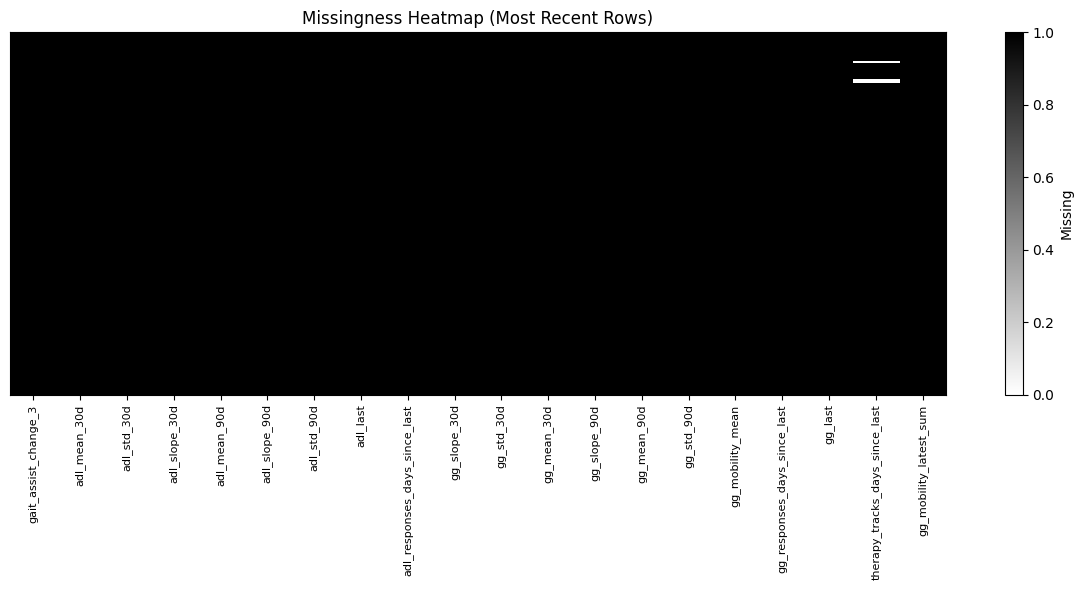

In [5]:
import matplotlib.pyplot as plt

missing_rate = df.isna().mean().sort_values(ascending=False)

top_n = 20
top_cols = missing_rate.head(top_n).index

sample_n = min(len(df), 400)

missing_sample = (
    df[top_cols]
    .isna()
    .astype(int)
    .tail(sample_n)
 )

plt.figure(figsize=(12, 6))
plt.imshow(missing_sample.values, aspect="auto", interpolation="nearest", cmap="binary")
plt.colorbar(label="Missing")
plt.xticks(range(len(top_cols)), top_cols, rotation=90, fontsize=8)
plt.yticks([])
plt.title("Missingness Heatmap (Most Recent Rows)")
plt.tight_layout()
plt.show()

- Missingness and zero-rate patterns are concentrated in a subset of engineered features.
- The heatmap provides a quick visual check for clustered missingness near the most recent snapshots.

## Near-Constant / Low Variance

In [6]:
low_variance_rows = []

for col in df.columns:
    series = df[col]
    nunique = series.nunique(dropna=True)
    if pd.api.types.is_numeric_dtype(series):
        variance = series.var(skipna=True)
        if nunique <= 1 or (variance is not None and variance <= 1e-12):
            low_variance_rows.append(
                {
                    "column": col,
                    "type": "numeric",
                    "nunique": int(nunique),
                    "variance": float(variance) if pd.notna(variance) else None,
                }
            )
    else:
        if nunique <= 1:
            low_variance_rows.append(
                {
                    "column": col,
                    "type": "non_numeric",
                    "nunique": int(nunique),
                    "variance": None,
                }
            )

if low_variance_rows:
    low_variance = pd.DataFrame(low_variance_rows).sort_values(
        ["nunique", "column"], ascending=[True, True]
    )
else:
    low_variance = pd.DataFrame(
        columns=["column", "type", "nunique", "variance"]
    )

low_variance.head(30)

,column,type,nunique,variance
1,gait_assist_change_3,numeric,0,NaN
0,gait_instability_flag,numeric,1,0.0


- Near-constant features detected here include gait_assist_change_3 (all null) and gait_instability_flag (single value).
- These are candidates for automatic removal prior to modeling.

## Per-Table Prefix Stats (FEATURE_TABLES)

In [7]:
prefix_rows = []

for prefix in FEATURE_TABLES:
    prefix_key = f"{prefix}_"
    cols = [c for c in df.columns if c.startswith(prefix_key)]
    if not cols:
        prefix_rows.append(
            {
                "table": prefix,
                "columns": 0,
                "missing_rate_mean": None,
                "zero_rate_mean": None,
            }
        )
        continue

    missing_mean = df[cols].isna().mean().mean()
    
    numeric_cols = df[cols].select_dtypes(include=["number"]).columns
    if len(numeric_cols) > 0:
        zero_mean = (df[numeric_cols] == 0).mean().mean()
    else:
        zero_mean = None

    prefix_rows.append(
        {
            "table": prefix,
            "columns": len(cols),
            "missing_rate_mean": float(missing_mean),
            "zero_rate_mean": float(zero_mean) if zero_mean is not None else None,
        }
    )

prefix_stats = pd.DataFrame(prefix_rows).sort_values(["columns", "table"], ascending=[False, True])
zero_prefixes = prefix_stats.loc[prefix_stats["columns"] == 0, "table"].tolist()
if zero_prefixes:
    print("No columns found for prefixes:", ", ".join(zero_prefixes))
prefix_stats

No columns found for prefixes: factors, injuries


,table,columns,missing_rate_mean,zero_rate_mean
14,vitals,83,0.387021,0.145373
0,adl_responses,4,0.243575,0.736850
2,diagnoses,4,0.055364,0.469297
3,document_tags,4,0.221926,0.675486
5,gg_responses,4,0.242015,0.733340
6,hospital_admissions,4,0.159614,0.622334
7,hospital_transfers,4,0.198458,0.680253
8,incidents,4,0.171196,0.607550
10,lab_reports,4,0.167853,0.576437
11,medications,4,0.222035,0.694015


- Prefix stats summarize missingness and zero rates by source table.
- No columns were found for the factors_ and injuries_ prefixes in this snapshot build.

## Label Prevalence

In [8]:
label_cols = [c for c in ["label_fall_30d", "label_rth_30d"] if c in df.columns]

label_stats = []
for col in label_cols:
    series = df[col]
    label_stats.append(
        {
            "label": col,
            "prevalence": float(series.mean()) if len(series) > 0 else None,
            "positives": int(series.sum()) if len(series) > 0 else None,
            "rows": int(len(series)),
        }
    )

labels_df = pd.DataFrame(label_stats)
labels_df

,label,prevalence,positives,rows
0,label_fall_30d,0.076253,4887,64089
1,label_rth_30d,0.026323,1687,64089


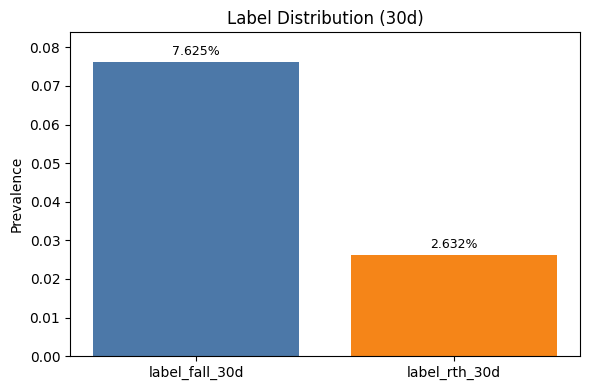

In [9]:
import matplotlib.pyplot as plt

labels_df = labels_df.sort_values("label")
plt.figure(figsize=(6, 4))
plt.bar(labels_df["label"], labels_df["prevalence"], color=["#4C78A8", "#F58518"][: len(labels_df)])
plt.ylabel("Prevalence")
plt.title("Label Distribution (30d)")
plt.ylim(0, max(labels_df["prevalence"].max() * 1.1, 0.01))
for idx, value in enumerate(labels_df["prevalence"]):
    plt.text(idx, value + 0.001, f"{value:.3%}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

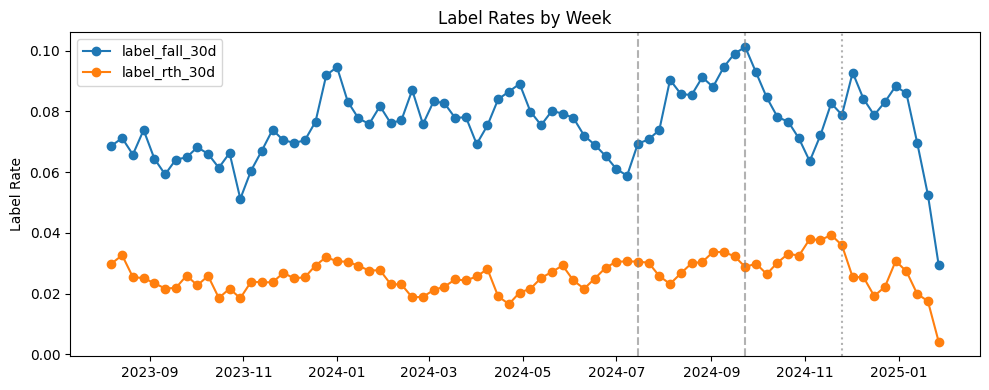

In [10]:
import matplotlib.pyplot as plt

label_cols = [c for c in ["label_fall_30d", "label_rth_30d"] if c in df.columns]
if not label_cols:
    raise ValueError("No label columns found in dataset.")

weekly = df[label_cols].copy()
weekly["date"] = date_series
weekly = weekly.dropna(subset=["date"])
weekly["week"] = weekly["date"].dt.to_period("W").apply(lambda p: p.start_time)
rate_df = weekly.groupby("week")[label_cols].mean().sort_index()

plt.figure(figsize=(10, 4))
for col in label_cols:
    plt.plot(rate_df.index, rate_df[col], marker="o", label=col)
plt.axvline(val_start, color="gray", linestyle="--", alpha=0.6)
plt.axvline(test_start, color="gray", linestyle="--", alpha=0.6)
plt.axvline(test_end, color="gray", linestyle=":", alpha=0.6)
plt.ylabel("Label Rate")
plt.title("Label Rates by Week")
plt.legend()
plt.tight_layout()
plt.show()

- Label prevalence: falls 7.63% (4,887 positives), RTH 2.63% (1,687 positives) over 64,089 rows.
- Weekly plots below check temporal stability around validation/test boundaries.

## Flagged Candidates

## Leakage Check

In [11]:
label_cols = [c for c in ["label_fall_30d", "label_rth_30d"] if c in df.columns]
suspicious_tokens = ["label", "target", "next_", "future", "outcome"]
suspicious_cols = [
    c
    for c in df.columns
    if any(tok in c.lower() for tok in suspicious_tokens) and c not in label_cols
 ]
if suspicious_cols:
    print("Potential leakage-like columns (review manually):")
    print(sorted(suspicious_cols)[:50])
else:
    print("No obvious leakage-like columns found by name.")

No obvious leakage-like columns found by name.


In [12]:
flags = []

missing_rate = df.isna().mean()
numeric_cols = df.select_dtypes(include=["number"]).columns
zero_rate = pd.Series(0.0, index=df.columns)
zero_rate.loc[numeric_cols] = (df[numeric_cols] == 0).mean()

for col in df.columns:
    series = df[col]
    nunique = series.nunique(dropna=True)
    variance = series.var(skipna=True) if pd.api.types.is_numeric_dtype(series) else None

    reasons = []
    if missing_rate[col] >= 0.9:
        reasons.append("missing>=0.90")
    if col in numeric_cols and zero_rate[col] >= 0.95:
        reasons.append("zero>=0.95")
    if nunique <= 1:
        reasons.append("nunique<=1")
    if variance is not None and variance <= 1e-12:
        reasons.append("variance<=1e-12")

    if reasons:
        flags.append(
            {
                "column": col,
                "missing_rate": float(missing_rate[col]),
                "zero_rate": float(zero_rate[col]) if col in numeric_cols else None,
                "nunique": int(nunique),
                "variance": float(variance) if variance is not None else None,
                "reasons": ";".join(reasons),
            }
        )

flagged = pd.DataFrame(flags).sort_values(
    ["missing_rate", "zero_rate", "nunique", "column"], ascending=[False, False, True, True]
 )
flagged.head(50)

,column,missing_rate,zero_rate,nunique,variance,reasons
45,gait_assist_change_3,1.000000,0.000000,0,NaN,missing>=0.90;nunique<=1
19,adl_slope_30d,0.975440,0.010017,115,0.034783,missing>=0.90
17,adl_mean_30d,0.975440,0.000047,1537,0.957584,missing>=0.90
18,adl_std_30d,0.975440,0.000047,1564,0.128148,missing>=0.90
23,adl_slope_90d,0.974816,0.009783,276,0.032358,missing>=0.90
21,adl_mean_90d,0.974816,0.000000,1595,0.940657,missing>=0.90
22,adl_std_90d,0.974816,0.000000,1603,0.120936,missing>=0.90
3,adl_responses_days_since_last,0.974301,0.022843,26,339.458723,missing>=0.90
16,adl_last,0.974301,0.008738,6,2.237882,missing>=0.90
28,gg_slope_30d,0.969183,0.011125,190,0.293645,missing>=0.90


- The flagged table surfaces columns with extreme missingness, zero inflation, or zero variance for manual review.

## Modeling Feature Set Decision

We will drop features manually based on the flagged table, while always keeping id/date columns and labels. The selected feature list below is for inspection only and is not saved to disk.

In [13]:
from pathlib import Path

label_cols = [c for c in ["label_fall_30d", "label_rth_30d"] if c in df.columns]
id_cols = [
    c
    for c in df.columns
    if c in ["resident_id", "facility_id", "patient_id", "person_id"]
 ]
date_like_cols = [
    c
    for c in df.columns
    if any(key in c.lower() for key in ["date", "dt", "time", "timestamp", "snapshot", "as_of", "week", "reference"])
]
protected_cols = set(label_cols + id_cols + date_like_cols)

# Fill these lists from the flagged table above.
manual_drop_cols = [
    # "example_feature_col",
]
manual_drop_prefixes = [
    # "lab_reports_",
]

# Auto-drop only constant/near-constant columns to avoid removing sparse signals.
auto_drop_cols = []
if "flagged" in globals():
    constant_reasons = {"nunique<=1", "variance<=1e-12"}
    for _, row in flagged.iterrows():
        reasons = set(str(row.get("reasons", "")).split(";"))
        if reasons & constant_reasons:
            col = row.get("column")
            if col and col not in protected_cols:
                auto_drop_cols.append(col)

feature_cols = [c for c in df.columns if c not in protected_cols]
drop_set = set(auto_drop_cols) | set(manual_drop_cols)
for prefix in manual_drop_prefixes:
    drop_set.update([c for c in feature_cols if c.startswith(prefix)])

selected_features = [c for c in feature_cols if c not in drop_set]

summary_rows = []
for prefix in FEATURE_TABLES:
    prefix_key = f"{prefix}_"
    kept = [c for c in selected_features if c.startswith(prefix_key)]
    summary_rows.append({"table": prefix, "kept_features": len(kept)})

summary = pd.DataFrame(summary_rows).sort_values(["kept_features", "table"], ascending=[False, True])
print(f"Selected features: {len(selected_features)}")
print(f"Protected columns (id/date/labels): {len(protected_cols)}")
print(f"Auto-dropped constant columns: {len(auto_drop_cols)}")
summary

Selected features: 197
Protected columns (id/date/labels): 5
Auto-dropped constant columns: 2


,table,kept_features
14,vitals,83
0,adl_responses,4
2,diagnoses,4
3,document_tags,4
5,gg_responses,4
6,hospital_admissions,4
7,hospital_transfers,4
8,incidents,4
10,lab_reports,4
11,medications,4


- Feature selection snapshot: 197 features kept, 5 protected columns (ids/dates/labels), and 2 auto-dropped constants.
- The kept-feature counts by table help validate coverage across source domains.

In [14]:
from sklearn.feature_selection import mutual_info_classif

label_cols = [c for c in ["label_fall_30d", "label_rth_30d"] if c in df.columns]
if not label_cols:
    raise ValueError("No label columns found.")
if "train_mask" not in globals():
    raise ValueError("train_mask not found. Run the split definitions cell first.")

id_cols = [c for c in df.columns if c in ["resident_id", "facility_id", "patient_id", "person_id"]]
date_like_cols = [c for c in df.columns if any(k in c.lower() for k in ["date", "dt", "time", "snapshot", "as_of", "week", "reference"])]
protected_cols = set(label_cols + id_cols + date_like_cols)

numeric_cols = [c for c in df.select_dtypes(include=["number"]).columns if c not in protected_cols]
X = df[numeric_cols].copy()
X = X.loc[:, X.isna().mean() <= 0.95]
medians = X.median(numeric_only=True)
X = X.fillna(medians)
X = X.drop(columns=[c for c in auto_drop_cols if c in X.columns], errors="ignore")

X_train = X.loc[train_mask].copy()
missing_rate_full = df[X.columns].isna().mean()

mi_raw_rows = []
for label in label_cols:
    y = df[label].astype(int)
    y_train = y.loc[train_mask]
    if y_train.nunique() < 2:
        continue
    mi_raw = mutual_info_classif(X_train, y_train, discrete_features=False, random_state=42)
    mi_series = pd.Series(mi_raw, index=X.columns)
    mi_raw_rows.append(mi_series.rename(label))

mi_raw_df = pd.concat(mi_raw_rows, axis=1) if mi_raw_rows else pd.DataFrame(index=X.columns)
mi_adjusted_df = mi_raw_df.mul(np.sqrt(1.0 - missing_rate_full), axis=0)

feature_stats = pd.DataFrame({
    "feature": mi_raw_df.index,
    "mi_raw": mi_raw_df.mean(axis=1) if not mi_raw_df.empty else 0.0,
    "mi_adjusted": mi_adjusted_df.mean(axis=1) if not mi_adjusted_df.empty else 0.0,
    "missing_rate": df[mi_raw_df.index].isna().mean().values,
    "variance": df[mi_raw_df.index].var(skipna=True).values,
})
feature_stats = feature_stats.sort_values(["mi_adjusted", "missing_rate"], ascending=[True, False])

mi_df = pd.DataFrame(index=mi_raw_df.index)
corr_threshold = 0.85
for label in mi_adjusted_df.columns:
    scores = mi_adjusted_df[label].dropna().sort_values(ascending=False)
    selected = []
    dropped = 0
    for feature in scores.index:
        if not selected:
            selected.append(feature)
            continue
        corr_vals = X_train[selected].corrwith(X_train[feature]).abs().fillna(0.0)
        if (corr_vals < corr_threshold).all():
            selected.append(feature)
        else:
            dropped += 1
        if len(selected) >= 100:
            break
    print(f"{label}: correlation-filtered out {dropped} features")
    filtered_scores = pd.Series(-np.inf, index=mi_adjusted_df.index, dtype=float)
    filtered_scores.loc[selected] = mi_adjusted_df.loc[selected, label]
    mi_df[label] = filtered_scores

low_signal = feature_stats.head(50)
print("Lowest signal features (by adjusted MI):")
low_signal

label_fall_30d: correlation-filtered out 29 features
label_rth_30d: correlation-filtered out 28 features
Lowest signal features (by adjusted MI):


,feature,mi_raw,mi_adjusted,missing_rate,variance
gg_mobility_latest_sum,gg_mobility_latest_sum,0.000000,0.000000,0.927523,211.107453
medications_days_since_last,medications_days_since_last,0.000000,0.000000,0.888140,2964.654934
los_91_180,los_91_180,0.000000,0.000000,0.000000,0.093935
gg_decline_30d,gg_decline_30d,0.000000,0.000000,0.000000,0.011474
med_risk_sedative_90d,med_risk_sedative_90d,0.000000,0.000000,0.000000,0.007572
adl_decline_30d,adl_decline_30d,0.000032,0.000032,0.000000,0.007818
comorb_osteoporosis,comorb_osteoporosis,0.000038,0.000038,0.000000,0.059582
gg_responses_count_30d,gg_responses_count_30d,0.000040,0.000040,0.000000,49445.112790
adl_responses_count_30d,adl_responses_count_30d,0.000142,0.000142,0.000000,31266.877224
adl_decline_90d,adl_decline_90d,0.000156,0.000156,0.000000,0.008508


- Correlation filtering removed 29 features for fall and 28 for RTH when building top MI lists.
- Adjusted MI downweights features with high missingness; low-signal features are listed for pruning.

## Feature Drift (PSI)

In [19]:
def psi_score(expected: pd.Series, actual: pd.Series, bins: int = 10) -> float:
    expected = expected.dropna()
    actual = actual.dropna()
    if expected.empty or actual.empty:
        return float("nan")
    quantiles = np.linspace(0, 1, bins + 1)
    breakpoints = np.unique(np.quantile(expected, quantiles))
    if len(breakpoints) <= 2:
        return float("nan")
    expected_counts, _ = np.histogram(expected, bins=breakpoints)
    actual_counts, _ = np.histogram(actual, bins=breakpoints)
    expected_perc = expected_counts / max(expected_counts.sum(), 1)
    actual_perc = actual_counts / max(actual_counts.sum(), 1)
    epsilon = 1e-6
    psi_vals = (actual_perc - expected_perc) * np.log((actual_perc + epsilon) / (expected_perc + epsilon))
    return float(np.sum(psi_vals))

if "date_series" not in globals():
    date_series = pd.to_datetime(df[date_col], errors="coerce")
if "train_mask" not in globals():
    train_mask = (date_series >= train_start) & (date_series <= train_end)
if "test_mask" not in globals():
    test_mask = (date_series >= test_start) & (date_series <= test_end)

if "feature_stats" in globals() and not feature_stats.empty:
    drift_features = feature_stats.sort_values("mi_adjusted", ascending=False)["feature"].head(30).tolist()
else:
    drift_features = df.select_dtypes(include=["number"]).columns[:30].tolist()

psi_rows = []
for feature in drift_features:
    psi_rows.append(
        {
            "feature": feature,
            "psi_train_test": psi_score(df.loc[train_mask, feature], df.loc[test_mask, feature]),
        }
    )
psi_df = pd.DataFrame(psi_rows).sort_values("psi_train_test", ascending=False)
psi_df.head(30)

,feature,psi_train_test
18,physician_orders_count_180d,0.098657
25,facility_fall_rate_90d,0.068009
27,facility_fall_90d,0.066517
23,physician_orders_count_90d,0.042547
16,care_plans_count_total,0.026084
21,vitals_o2_sats_std_90d,0.024117
17,vitals_bp_systolic_mean_90d,0.017855
13,vitals_bp_systolic_std_90d,0.017132
15,vitals_pulse_std_90d,0.012463
4,vitals_weight_std_90d,0.011879


- PSI is computed on a subset of top MI features to flag train/test drift candidates.
- Review high-PSI features first when assessing temporal stability.

## Correlation Check (Top MI Features)

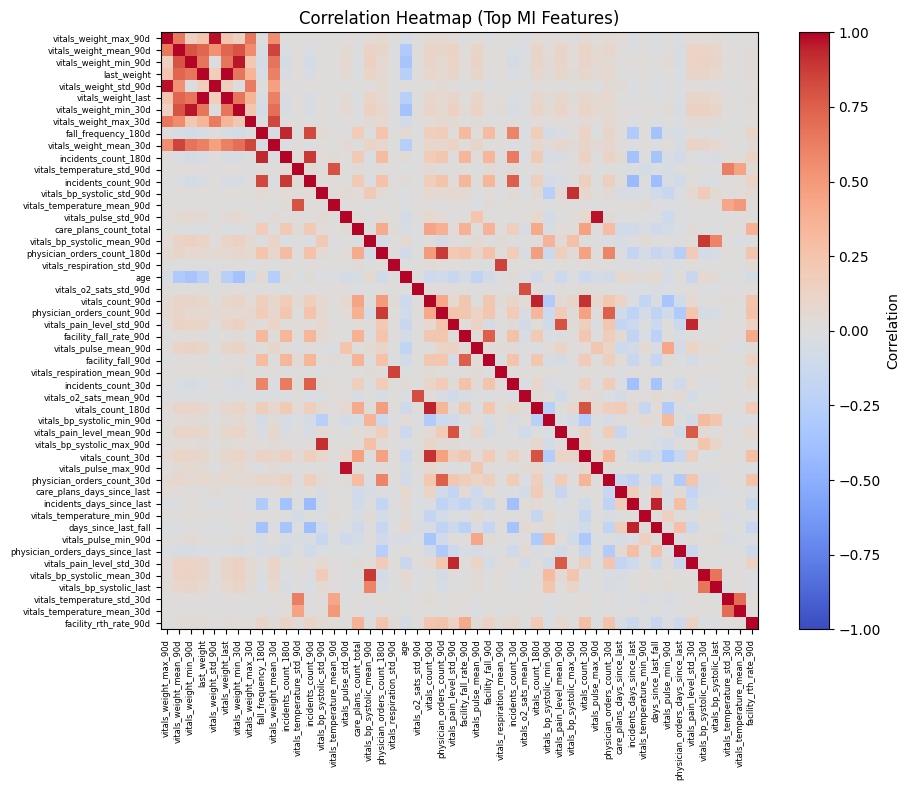

In [16]:
import matplotlib.pyplot as plt

if "feature_stats" in globals() and not feature_stats.empty:
    corr_features = feature_stats.sort_values("mi_adjusted", ascending=False)["feature"].head(50).tolist()
else:
    corr_features = df.select_dtypes(include=["number"]).columns[:50].tolist()

corr = df[corr_features].corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_features)), corr_features, rotation=90, fontsize=6)
plt.yticks(range(len(corr_features)), corr_features, fontsize=6)
plt.title("Correlation Heatmap (Top MI Features)")
plt.tight_layout()
plt.show()

In [17]:
high_signal = feature_stats.sort_values("mi_adjusted", ascending=False).head(20)
print("Top signal features (by adjusted MI):")
high_signal

Top signal features (by adjusted MI):


,feature,mi_raw,mi_adjusted,missing_rate,variance
vitals_weight_max_90d,vitals_weight_max_90d,0.055950,0.047097,0.291423,122327.858608
vitals_weight_mean_90d,vitals_weight_mean_90d,0.053799,0.045286,0.291423,4641.458208
vitals_weight_min_90d,vitals_weight_min_90d,0.049154,0.041377,0.291423,3341.434202
last_weight,last_weight,0.039390,0.033505,0.276491,6587.852626
vitals_weight_std_90d,vitals_weight_std_90d,0.039357,0.033129,0.291423,10708.696915
vitals_weight_last,vitals_weight_last,0.038888,0.033078,0.276491,6587.852626
vitals_weight_min_30d,vitals_weight_min_30d,0.037974,0.030354,0.361045,3288.465759
vitals_weight_max_30d,vitals_weight_max_30d,0.037651,0.030096,0.361045,57240.954532
fall_frequency_180d,fall_frequency_180d,0.026398,0.026398,0.000000,2.534859
vitals_weight_mean_30d,vitals_weight_mean_30d,0.032559,0.026026,0.361045,6398.029203


- The high-signal feature list provides a quick sanity check on the strongest predictors by adjusted MI.

In [18]:
top_n = 100
top_features = {}

for label in label_cols:
    if label not in mi_df.columns:
        continue
    top_list = (
        mi_df[label]
        .replace(-np.inf, np.nan)
        .dropna()
        .sort_values(ascending=False)
        .head(top_n)
        .index
        .tolist()
    )
    top_features[label] = top_list
    out_path = root / "outputs" / f"selected_features_top100_{label}.csv"
    pd.Series(top_list, name="feature").to_csv(out_path, index=False)
    print(f"Saved {len(top_list)} features to {out_path}")
    missing_share = df[top_list].isna().mean()
    high_missing = missing_share[missing_share > 0.5]
    print(f"Top-100 with missing_rate > 0.5: {len(high_missing)}")

if len(top_features) >= 2:
    labels = list(top_features.keys())
    left = set(top_features[labels[0]])
    right = set(top_features[labels[1]])
    overlap = sorted(left & right)
    print(f"Overlap count ({labels[0]} vs {labels[1]}): {len(overlap)}")
    print("Overlap sample:", overlap[:20])

Saved 100 features to /Users/marcelo.florencio/workspace/personal/tricura-incident-risk/outputs/selected_features_top100_label_fall_30d.csv
Top-100 with missing_rate > 0.5: 12
Saved 100 features to /Users/marcelo.florencio/workspace/personal/tricura-incident-risk/outputs/selected_features_top100_label_rth_30d.csv
Top-100 with missing_rate > 0.5: 13
Overlap count (label_fall_30d vs label_rth_30d): 88
Overlap sample: ['age', 'care_plans_count_total', 'care_plans_days_since_last', 'comorb_ckd', 'comorb_dementia', 'comorb_depression', 'comorb_diabetes', 'comorbidity_count', 'days_since_admission', 'diagnoses_count_180d', 'diagnoses_count_30d', 'diagnoses_count_90d', 'diagnoses_days_since_last', 'diagnosis_high_risk_flag', 'facility_fall_90d', 'facility_fall_rate_90d', 'facility_residents', 'facility_rth_90d', 'facility_rth_rate_90d', 'fall_injury_count_180d']


- Top-100 feature lists are saved per label; missingness within the top-100 is still notable (12 for fall, 13 for RTH above 0.5 missing rate).
- Overlap between fall and RTH top-100 features is high (88 shared features), suggesting shared risk signals.

## Summary and Next Steps
- Datavision snapshots show manageable label prevalence and stable weekly rates across the split windows.
- Feature screening highlights a small set of constant/near-constant columns and a concentrated set of sparse features.
- Proceed to model notebooks to validate performance with the selected feature set and temporal split.